# LIF test v2

Same workflow as the MATLAB GENERATE / Estimate / Analyze scripts:

1. **Define** functions (integrate-and-fire **v2** plus helpers still used later)
2. **Estimate** the A × R_bg grid
3. **Save** the full grid
4. **Analyze** (CCG, coincidence-event phases, CCG features, cycle PSTH, phase locking)

The original `LIF test.ipynb` is left unchanged. Draft simulators (`simulate_lif`, two-neuron, v1 `simulate_n_lif_same_input`) and `autocorrelogram` are not copied — they are not used after v2.

There was **no PPC** in the original LIF notebook. The phase-locking helper that *was* defined is `compute_mvl`. A small `compute_ppc` matching `Custom functions/ppc.m` is included so both can be applied to the v2 spike trains.


## 1. Define functions

In [27]:
import numpy as np
import pickle
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Same filename as LIF test.ipynb (save there, load here).
CHECKPOINT_FILE = Path("sim_shared_grid.pkl")
# CHECKPOINT_FILE = Path("sim_NOT_shared_grid.pkl")


# ============================================================
# INTEGRATE-AND-FIRE v2  (shared vs independent oscillatory input)
# ============================================================

def simulate_n_lif_same_input_v2(
    n_neurons=10,
    T=20.0,
    dt=0.001,
    tau_m=0.02,
    V_rest=-65.0,
    V_reset=-70.0,
    V_thresh=-50.0,
    refractory=0.005,
    tau_s=0.015,
    R_bg=20,
    A=20,
    f=8,
    B=20,
    w_bg=10,
    w_osc=15,
    is_shared=True,
):
    n_steps = int(T / dt)
    time = np.arange(n_steps) * dt

    if np.isscalar(R_bg):
        R_bg = np.full(n_neurons, R_bg)

    V = np.zeros((n_neurons, n_steps))
    V[:, 0] = V_rest
    I = np.zeros((n_neurons, n_steps))
    spikes_out = np.zeros((n_neurons, n_steps))
    ref_count = np.zeros(n_neurons, dtype=int)
    rate2_array = np.zeros(n_steps)

    decay = np.exp(-dt / tau_s)
    ref_steps = int(refractory / dt)

    for t in range(1, n_steps):
        rate2 = A * np.sin(2 * np.pi * f * time[t]) + B
        rate2 = max(rate2, 0)
        rate2_array[t] = rate2
        p_osc = 1 - np.exp(-rate2 * dt)

        bg_spikes = np.random.rand(n_neurons) < R_bg * dt

        if is_shared:
            osc_spike = np.random.rand() < p_osc
            osc_spikes = np.full(n_neurons, osc_spike)
        else:
            osc_spikes = np.random.rand(n_neurons) < p_osc

        I[:, t] = decay * I[:, t - 1] + w_bg * bg_spikes + w_osc * osc_spikes

        refractory_mask = ref_count > 0
        V[refractory_mask, t] = V_reset
        ref_count[refractory_mask] -= 1

        active = ~refractory_mask
        dV = (-(V[active, t - 1] - V_rest) + I[active, t]) * (dt / tau_m)
        V[active, t] = V[active, t - 1] + dV

        spiking = active & (V[:, t] >= V_thresh)
        spikes_out[spiking, t] = 1
        V[spiking, t] = V_reset
        ref_count[spiking] = ref_steps

    return time, V, spikes_out, rate2_array


# ============================================================
# PHASE LOCKING: MVL (from original LIF test) and PPC (ppc.m)
# ============================================================

def compute_mvl(spike_times, f):
    phases = (2 * np.pi * f * np.asarray(spike_times)) % (2 * np.pi)
    if phases.size == 0:
        return phases, np.nan, np.nan
    vector = np.exp(1j * phases)
    mvl = np.abs(np.mean(vector))
    mean_phase = np.angle(np.mean(vector))
    return phases, mvl, mean_phase


def compute_ppc(phases):
    """Pairwise phase consistency: mean cos(phi_i - phi_j) over unique pairs."""
    phases = np.asarray(phases).ravel()
    n = phases.size
    if n < 2:
        return np.nan
    dphi = phases[:, None] - phases[None, :]
    iu = np.triu_indices(n, k=1)
    return float(np.mean(np.cos(dphi[iu])))


# ============================================================
# PSTH AROUND OSCILLATION PEAKS
# ============================================================

def compute_psth_around_peaks(time, spikes_out, f, dt):
    period = 2 / f
    peak_times = np.arange(1 / (4 * f), time[-1], period)
    window = 2 * period
    half_window = window / 2
    bins = np.arange(-half_window, half_window, dt)
    psth = np.zeros(len(bins) - 1)
    spike_times = time[spikes_out == 1]
    n_trials = 0

    for peak in peak_times:
        aligned_spikes = spike_times - peak
        aligned_spikes = aligned_spikes[
            (aligned_spikes >= -half_window) & (aligned_spikes <= half_window)
        ]
        counts, _ = np.histogram(aligned_spikes, bins=bins)
        psth += counts
        n_trials += 1

    psth = psth / (n_trials * dt)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    return bin_centers, psth


# ============================================================
# SINUSOID FIT
# ============================================================

def sinusoid(t, b1, b2, b3):
    return b1 * np.sin(2 * np.pi * b2 * t) + b3


def fit_sinusoid(t, psth, f):
    initial_guess = [np.max(psth), f, np.mean(psth)]
    params, _ = curve_fit(sinusoid, t, psth, p0=initial_guess, maxfev=5000)
    return params


# ============================================================
# CROSS-CORRELOGRAM
# ============================================================

def ccg_pair(t1, t2, bins):
    diffs = np.subtract.outer(t2, t1).ravel()
    return np.histogram(diffs, bins=bins)[0]


def extract_ccg_features(ccg, lags):
    center_idx = np.argmin(np.abs(lags))
    ccg_center = ccg[center_idx]
    ccg_peak = np.max(ccg)
    peak_to_mean = ccg_peak / (np.mean(ccg) + 1e-12)
    peak_to_min = ccg_peak / (np.min(ccg) + 1e-12)
    norm_peak = (ccg_peak - np.mean(ccg)) / (np.mean(ccg) + 1e-12)
    left = np.mean(ccg[lags < 0])
    right = np.mean(ccg[lags > 0])
    asymmetry = (right - left) / (right + left + 1e-12)
    return {
        "center": ccg_center,
        "peak": ccg_peak,
        "peak_ratio": peak_to_mean,
        "norm_peak": norm_peak,
        "asymmetry": asymmetry,
        "peak2min": peak_to_min,
    }


# ============================================================
# COINCIDENT EVENTS (same 5 ms window as MATLAB time_precision)
# ============================================================

def coincident_event_times(t1, t2, window=0.005):
    """Spike times in t1 that have a partner in t2 within ±window."""
    t1 = np.asarray(t1)
    t2 = np.asarray(t2)
    if t1.size == 0 or t2.size == 0:
        return t1[:0]
    t2 = np.sort(t2)
    j = np.searchsorted(t2, t1)
    nearest = np.full(t1.size, np.inf)
    lo = j > 0
    nearest[lo] = np.minimum(nearest[lo], np.abs(t1[lo] - t2[j[lo] - 1]))
    hi = j < t2.size
    nearest[hi] = np.minimum(nearest[hi], np.abs(t2[j[hi]] - t1[hi]))
    return t1[nearest <= window]


def oscillation_phase(event_times, f):
    """Phase of the sine drive at event times, wrapped to [0, 2π)."""
    return (2 * np.pi * f * np.asarray(event_times)) % (2 * np.pi)


## 2. Estimate

Run this once. Skip it later and use **Load** instead.

Each grid point is 20 neurons × 100 s at `dt = 1 ms` (64 runs). This takes a while.


In [ ]:
# ============================================================
# PARAM GRID  (same as the last v2 loop in LIF test.ipynb)
# ============================================================

A_vals = np.arange(1, 31, 4)
R_vals = np.arange(1, 31, 4)

sim_params = dict(
    n_neurons=20,
    T=100,
    dt=0.001,
    tau_m=0.02,
    V_rest=-65.0,
    V_reset=-70.0,
    V_thresh=-50.0,
    refractory=0.005,
    tau_s=0.015,
    f=3,
    w_bg=10,
    w_osc=15,
    is_shared=True,  # False → independent oscillatory Poisson per neuron
)

results = []

for A in A_vals:
    for R_bg in R_vals:
        print(f"Running A={A}, R_bg={R_bg}")
        time, V, spikes_out, rate2_array = simulate_n_lif_same_input_v2(
            n_neurons=sim_params["n_neurons"],
            T=sim_params["T"],
            dt=sim_params["dt"],
            tau_m=sim_params["tau_m"],
            V_rest=sim_params["V_rest"],
            V_reset=sim_params["V_reset"],
            V_thresh=sim_params["V_thresh"],
            refractory=sim_params["refractory"],
            tau_s=sim_params["tau_s"],
            R_bg=R_bg,
            A=A,
            f=sim_params["f"],
            B=A,
            w_bg=sim_params["w_bg"],
            w_osc=sim_params["w_osc"],
            is_shared=sim_params["is_shared"],
        )
        results.append({
            "A": A,
            "R_bg": R_bg,
            "time": time,
            "spikes_out": spikes_out,
        })

print(f"Finished {len(results)} runs")


## 3. Save

In [ ]:
with open(CHECKPOINT_FILE, "wb") as fh:
    pickle.dump({
        "A_vals": A_vals,
        "R_vals": R_vals,
        "results": results,
        "sim_params": sim_params,
    }, fh)

print(f"Saved {len(results)} runs to {CHECKPOINT_FILE.resolve()}")


## 4. Load

Skip **Estimate**. Load the pickle from this notebook's **Save**, or from `LIF test.ipynb` (`sim_shared_grid.pkl`).


In [28]:
candidates = [
    CHECKPOINT_FILE,
    Path("sim_shared_grid.pkl"),
    Path("LIF_v2_sim_shared_grid.pkl"),
]
load_path = next((p for p in candidates if p.exists()), None)
if load_path is None:
    raise FileNotFoundError(
        "No checkpoint found. Save from LIF test.ipynb "
        f"or this notebook. Looked for: {[str(p) for p in candidates]}"
    )

with open(load_path, "rb") as fh:
    ckpt = pickle.load(fh)

A_vals = ckpt["A_vals"]
R_vals = ckpt["R_vals"]
results = ckpt["results"]
sim_params = ckpt.get("sim_params") or {
    "n_neurons": results[0]["spikes_out"].shape[0],
    "T": float(results[0]["time"][-1]),
    "dt": float(results[0]["time"][1] - results[0]["time"][0]),
    "f": 3,
    "is_shared": True,
}
CHECKPOINT_FILE = load_path

print(f"Loaded {len(results)} runs from {load_path.resolve()}")
print("A_vals:", A_vals)
print("R_vals:", R_vals)
print("sim_params:", sim_params)


Loaded 64 runs from \\experimentfs.bccn-berlin.pri\experiment\PlayNeuralData\NPX-OPTO PLAY NMM\PlayBout Analysis\play bout analysis behavior and physiology\Complementary figures\sim_shared_grid.pkl
A_vals: [ 0  4  8 12 16 20 24 28]
R_vals: [ 0  4  8 12 16 20 24 28]
sim_params: {'n_neurons': 20, 'T': 99.999, 'dt': 0.001, 'f': 3, 'is_shared': True}


## 5. Analyze

### 5.1 Pairwise CCG maps

In [29]:
max_lag = 0.2
bin_size = 0.005
bins = np.arange(-max_lag, max_lag + bin_size, bin_size)
lags = bins[:-1] + bin_size / 2

grouped = defaultdict(list)
for r in results:
    grouped[(r["A"], r["R_bg"])].append(r)

mean_ccg_map = {}
sem_ccg_map = {}

for key in grouped:
    all_ccgs = []
    for trial in grouped[key]:
        spikes_out = trial["spikes_out"]
        time = trial["time"]
        spike_times = [
            time[spikes_out[i] == 1]
            for i in range(spikes_out.shape[0])
        ]
        n_neurons = spikes_out.shape[0]
        for i in range(n_neurons):
            for j in range(i + 1, n_neurons):
                t1, t2 = spike_times[i], spike_times[j]
                if len(t1) == 0 or len(t2) == 0:
                    continue
                ccg = ccg_pair(t1, t2, bins)
                if ccg.shape[0] == len(bins) - 1:
                    all_ccgs.append(ccg)

    if len(all_ccgs) > 0:
        all_ccgs = np.vstack(all_ccgs)
        mean_ccg_map[key] = np.mean(all_ccgs, axis=0)
        sem_ccg_map[key] = np.std(all_ccgs, axis=0) / np.sqrt(len(all_ccgs))
    else:
        mean_ccg_map[key] = np.full(len(bins) - 1, np.nan)
        sem_ccg_map[key] = np.full(len(bins) - 1, np.nan)

print(f"CCG maps for {len(mean_ccg_map)} (A, R_bg) keys")


CCG maps for 64 (A, R_bg) keys


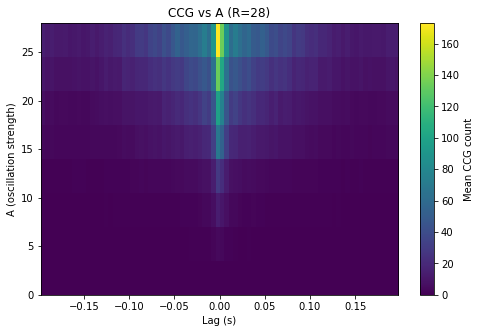

In [35]:
R_target = R_vals[7]  # choose background rate from the grid

A_plot = []
ccg_matrix = []
for A in A_vals:
    key = (A, R_target)
    if key in mean_ccg_map:
        A_plot.append(A)
        ccg_matrix.append(mean_ccg_map[key])

ccg_matrix = np.nan_to_num(np.array(ccg_matrix), nan=0.0)

plt.figure(figsize=(8, 5))
plt.imshow(
    ccg_matrix,
    aspect="auto",
    origin="lower",
    extent=[lags[0], lags[-1], A_plot[0], A_plot[-1]],
)
plt.colorbar(label="Mean CCG count")
plt.xlabel("Lag (s)")
plt.ylabel("A (oscillation strength)")
plt.title(f"CCG vs A (R={R_target})")
plt.show()


### 5.1b Polar histogram of coincident-event phases

Same 5 ms window as the CCG zero-lag bin and as MATLAB `time_precision`. Phase is that of the sine drive (`2π f t`) at each coincident spike. Uses `R_target` from the CCG plot above. Re-run **Define** if `coincident_event_times` is not defined.


In [36]:
coincidence_window = 0.005  # 5 ms
f_osc = sim_params["f"]
n_phase_bins = 18

coincidence_phase_map = {}

for r in results:
    key = (r["A"], r["R_bg"])
    time = r["time"]
    spikes_out = r["spikes_out"]
    n_neurons = spikes_out.shape[0]
    spike_times = [
        time[spikes_out[i] == 1]
        for i in range(n_neurons)
    ]

    phases = []
    for i in range(n_neurons):
        for j in range(i + 1, n_neurons):
            t1, t2 = spike_times[i], spike_times[j]
            if len(t1) == 0 or len(t2) == 0:
                continue
            coinc_t = coincident_event_times(t1, t2, window=coincidence_window)
            if coinc_t.size:
                phases.append(oscillation_phase(coinc_t, f_osc))

    coincidence_phase_map[key] = (
        np.concatenate(phases) if phases else np.array([])
    )

n_events = sum(v.size for v in coincidence_phase_map.values())
print(f"Collected {n_events} coincident events across {len(coincidence_phase_map)} (A, R) keys")
print(f"R_target = {R_target}, f = {f_osc} Hz, window = {coincidence_window * 1e3:.0f} ms")


Collected 1235733 coincident events across 64 (A, R) keys
R_target = 28, f = 3 Hz, window = 5 ms


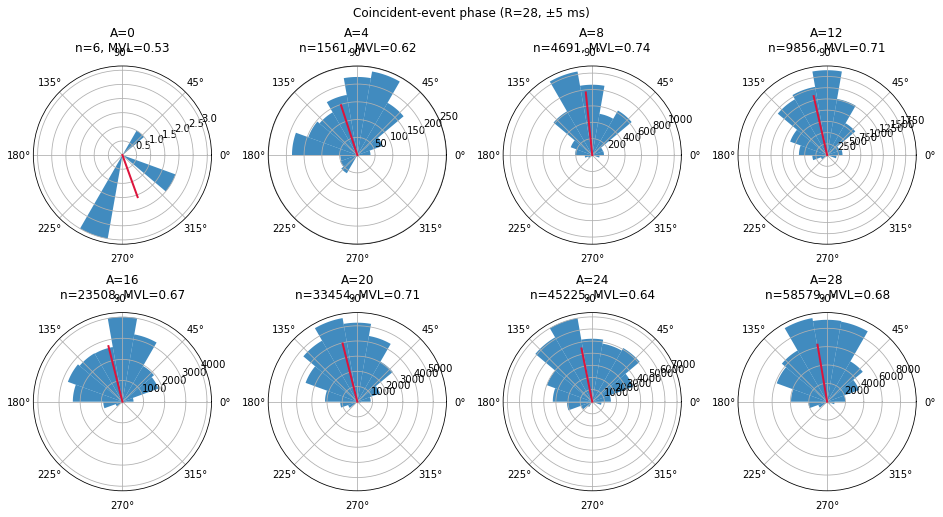

In [37]:
A_plot_coinc = [A for A in A_vals if (A, R_target) in coincidence_phase_map]
nA = len(A_plot_coinc)
ncols = min(nA, 4)
nrows = int(np.ceil(nA / ncols)) if nA else 1

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(3.3 * ncols, 3.5 * nrows),
    subplot_kw=dict(projection="polar"),
)
axes = np.atleast_1d(axes).ravel()

for ax, A in zip(axes, A_plot_coinc):
    phases = coincidence_phase_map[(A, R_target)]
    if phases.size == 0:
        ax.set_title(f"A={A}\nno events")
        continue

    counts, edges = np.histogram(phases, bins=n_phase_bins, range=(0, 2 * np.pi))
    centers = (edges[:-1] + edges[1:]) / 2
    width = np.diff(edges)
    ax.bar(centers, counts, width=width, align="center", edgecolor="none", alpha=0.85)

    vec = np.mean(np.exp(1j * phases))
    mvl = np.abs(vec)
    rmax = max(counts.max(), 1)
    ax.plot([0, np.angle(vec)], [0, mvl * rmax], color="crimson", lw=2)
    ax.set_title(f"A={A}\nn={phases.size}, MVL={mvl:.2f}")

for ax in axes[nA:]:
    ax.set_visible(False)

fig.suptitle(
    f"Coincident-event phase (R={R_target}, ±{coincidence_window * 1e3:.0f} ms)",
    y=1.02,
)
plt.tight_layout()
plt.show()


### 5.1c Polar histogram vs background rate R (fixed low A)

Same coincident-event phases as above, now holding oscillation strength **A** at its lowest grid value and varying independent Poisson rate **R**. Change `A_target` if you want a stronger drive.


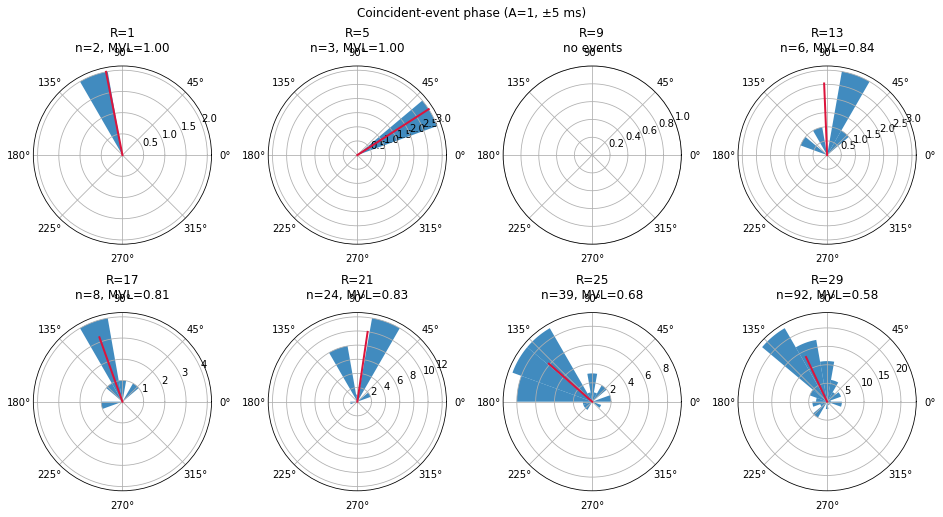

In [26]:
A_target = A_vals[0]  # lowest oscillation strength; raise this to compare a stronger drive

R_plot_coinc = [R for R in R_vals if (A_target, R) in coincidence_phase_map]
nR = len(R_plot_coinc)
ncols = min(nR, 4)
nrows = int(np.ceil(nR / ncols)) if nR else 1

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(3.3 * ncols, 3.5 * nrows),
    subplot_kw=dict(projection="polar"),
)
axes = np.atleast_1d(axes).ravel()

for ax, R in zip(axes, R_plot_coinc):
    phases = coincidence_phase_map[(A_target, R)]
    if phases.size == 0:
        ax.set_title(f"R={R}\nno events")
        continue

    counts, edges = np.histogram(phases, bins=n_phase_bins, range=(0, 2 * np.pi))
    centers = (edges[:-1] + edges[1:]) / 2
    width = np.diff(edges)
    ax.bar(centers, counts, width=width, align="center", edgecolor="none", alpha=0.85)

    vec = np.mean(np.exp(1j * phases))
    mvl = np.abs(vec)
    rmax = max(counts.max(), 1)
    ax.plot([0, np.angle(vec)], [0, mvl * rmax], color="crimson", lw=2)
    ax.set_title(f"R={R}\nn={phases.size}, MVL={mvl:.2f}")

for ax in axes[nR:]:
    ax.set_visible(False)

fig.suptitle(
    f"Coincident-event phase (A={A_target}, ±{coincidence_window * 1e3:.0f} ms)",
    y=1.02,
)
plt.tight_layout()
plt.show()


### 5.2 Rate-normalized CCG features

In [5]:
feature_table = []

for r in results:
    A = r["A"]
    R = r["R_bg"]
    spikes_out = r["spikes_out"]
    time = r["time"]
    spike_times = [
        time[spikes_out[i] == 1]
        for i in range(spikes_out.shape[0])
    ]
    n = spikes_out.shape[0]
    T = time[-1] - time[0]
    bin_width = bins[1] - bins[0]

    for i in range(n):
        for j in range(i + 1, n):
            if len(spike_times[i]) < 2 or len(spike_times[j]) < 2:
                continue
            t_i, t_j = spike_times[i], spike_times[j]
            r_i = len(t_i) / T
            r_j = len(t_j) / T
            ccg = ccg_pair(t_i, t_j, bins)
            expected = r_i * r_j * T * bin_width
            ccg_rate_norm = ccg / (expected + 1e-12)
            feats = extract_ccg_features(ccg_rate_norm, lags)
            feature_table.append({
                "A": A,
                "R": R,
                "pair": (i, j),
                "ri": r_i,
                "rj": r_j,
                "expected": expected,
                **feats,
            })

print(f"{len(feature_table)} pair-level CCG feature rows")


11411 pair-level CCG feature rows


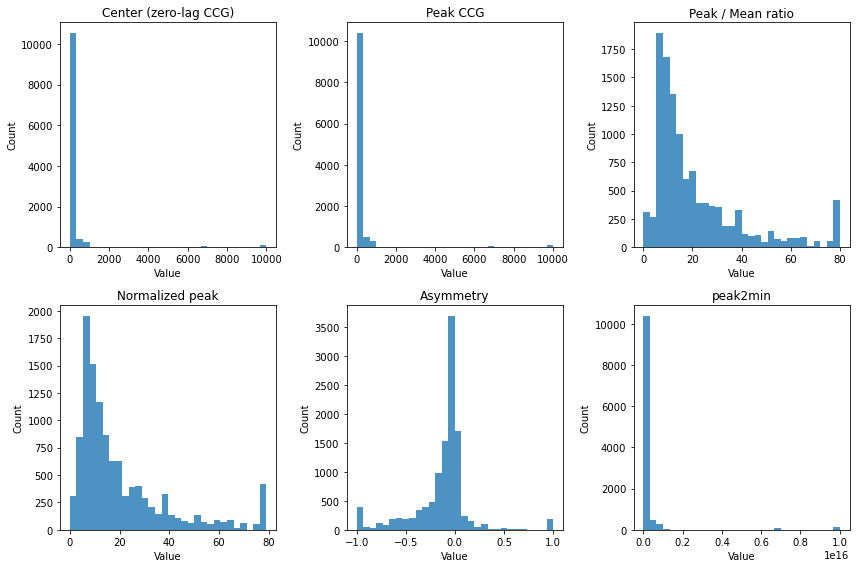

In [6]:
feat_A = np.array([row["A"] for row in feature_table])
feat_R = np.array([row["R"] for row in feature_table])
feat_center = np.array([row["center"] for row in feature_table])
feat_peak = np.array([row["peak"] for row in feature_table])
feat_peak_ratio = np.array([row["peak_ratio"] for row in feature_table])
feat_norm_peak = np.array([row["norm_peak"] for row in feature_table])
feat_asymmetry = np.array([row["asymmetry"] for row in feature_table])
feat_peak2min = np.array([row["peak2min"] for row in feature_table])

features = {
    "Center (zero-lag CCG)": feat_center,
    "Peak CCG": feat_peak,
    "Peak / Mean ratio": feat_peak_ratio,
    "Normalized peak": feat_norm_peak,
    "Asymmetry": feat_asymmetry,
    "peak2min": feat_peak2min,
}

plt.figure(figsize=(12, 8))
for i, (name, vals) in enumerate(features.items(), 1):
    plt.subplot(2, 3, i)
    plt.hist(vals, bins=30, alpha=0.8)
    plt.title(name)
    plt.xlabel("Value")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()


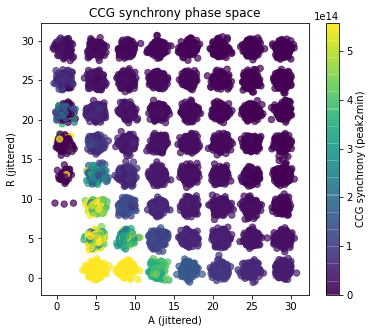

In [7]:
sync = feat_peak2min  # or feat_center / feat_peak / feat_peak_ratio / feat_norm_peak / feat_asymmetry

A_jitter, R_jitter = 0.5, 0.5
A_plot = feat_A + np.random.normal(0, A_jitter, size=len(feat_A))
R_plot = feat_R + np.random.normal(0, R_jitter, size=len(feat_R))

plt.figure(figsize=(6, 5))
plt.scatter(
    A_plot,
    R_plot,
    c=sync,
    cmap="viridis",
    alpha=0.7,
    s=40,
    vmin=np.percentile(sync, 5),
    vmax=np.percentile(sync, 95),
)
plt.colorbar(label="CCG synchrony (peak2min)")
plt.xlabel("A (jittered)")
plt.ylabel("R (jittered)")
plt.title("CCG synchrony phase space")
plt.show()


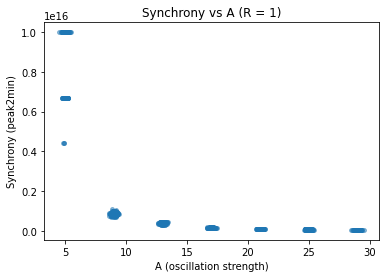

In [8]:
R_target = R_vals[0]  # pick a grid value, not an index into feature_table

mask = feat_R == R_target
A_slice = feat_A[mask]
sync_slice = sync[mask]
A_plot = A_slice + np.random.normal(0, 0.15, len(A_slice))

plt.figure(figsize=(6, 4))
plt.scatter(A_plot, sync_slice, alpha=0.5, s=15)
plt.xlabel("A (oscillation strength)")
plt.ylabel("Synchrony (peak2min)")
plt.title(f"Synchrony vs A (R = {R_target})")
plt.show()


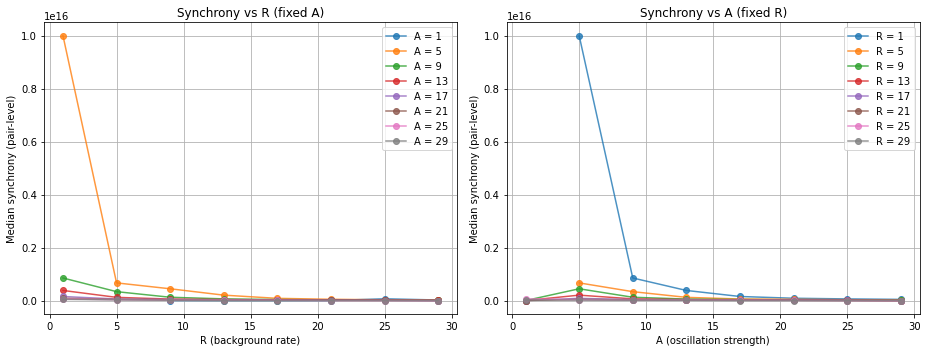

In [9]:
A_unique = np.unique(A_vals)
R_unique = np.unique(R_vals)

median_curves = {}
for R in R_unique:
    medians = []
    for A in A_unique:
        values = sync[(feat_R == R) & (feat_A == A)]
        medians.append(np.nan if len(values) == 0 else np.median(values))
    median_curves[R] = np.array(medians)

median_curves_A = {}
for A in A_unique:
    medians = []
    for R in R_unique:
        values = sync[(feat_A == A) & (feat_R == R)]
        medians.append(np.nan if len(values) == 0 else np.median(values))
    median_curves_A[A] = np.array(medians)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for A in A_unique:
    axes[0].plot(R_unique, median_curves_A[A], marker="o", alpha=0.8, label=f"A = {A}")
axes[0].set_xlabel("R (background rate)")
axes[0].set_ylabel("Median synchrony (pair-level)")
axes[0].set_title("Synchrony vs R (fixed A)")
axes[0].legend()
axes[0].grid(True)

for R in R_unique:
    axes[1].plot(A_unique, median_curves[R], marker="o", alpha=0.8, label=f"R = {R}")
axes[1].set_xlabel("A (oscillation strength)")
axes[1].set_ylabel("Median synchrony (pair-level)")
axes[1].set_title("Synchrony vs A (fixed R)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### 5.3 Cycle PSTH + sinusoid fit

In [10]:
f_osc = sim_params["f"]
feature_psth_table = []

for r in results:
    A = r["A"]
    R = r["R_bg"]
    time = r["time"]
    spikes_out = r["spikes_out"]
    dt = time[1] - time[0]
    n_neurons = spikes_out.shape[0]

    for neuron_id in range(n_neurons):
        bin_centers, psth = compute_psth_around_peaks(
            time, spikes_out[neuron_id], f=f_osc, dt=dt
        )
        try:
            b1, b2, b3 = fit_sinusoid(bin_centers, psth, f=f_osc)
        except RuntimeError:
            b1, b2, b3 = np.nan, np.nan, np.nan

        feature_psth_table.append({
            "A": A,
            "R": R,
            "neuron": neuron_id,
            "b1": b1,
            "b2": b2,
            "b3": b3,
        })

print(f"{len(feature_psth_table)} neuron-level PSTH rows")


C:\ProgramData\Anaconda3\lib\site-packages\scipy\optimize\_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
1280 neuron-level PSTH rows


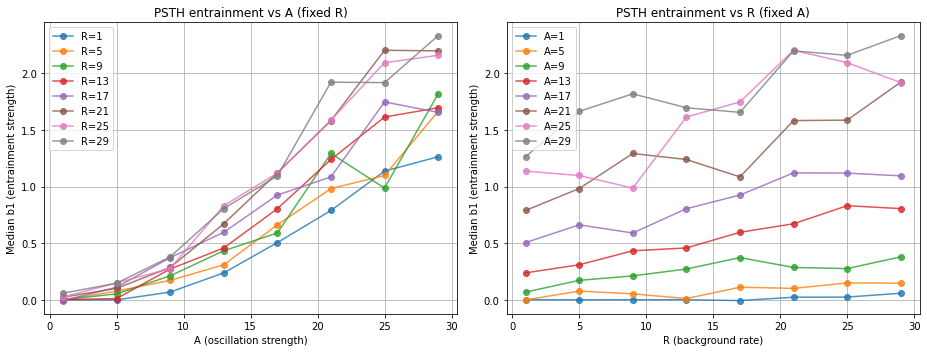

In [11]:
psth_A = np.array([row["A"] for row in feature_psth_table])
psth_R = np.array([row["R"] for row in feature_psth_table])
b1_vals = np.array([row["b1"] for row in feature_psth_table])
b2_vals = np.array([row["b2"] for row in feature_psth_table])
b3_vals = np.array([row["b3"] for row in feature_psth_table])

median_b1_curves_A = {}
median_b1_curves_R = {}

for A in A_unique:
    medians = []
    for R in R_unique:
        sel = b1_vals[(psth_A == A) & (psth_R == R)]
        medians.append(np.nan if len(sel) == 0 else np.nanmedian(sel))
    median_b1_curves_A[A] = np.array(medians)

for R in R_unique:
    medians = []
    for A in A_unique:
        sel = b1_vals[(psth_A == A) & (psth_R == R)]
        medians.append(np.nan if len(sel) == 0 else np.nanmedian(sel))
    median_b1_curves_R[R] = np.array(medians)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for R in R_unique:
    axes[0].plot(A_unique, median_b1_curves_R[R], marker="o", alpha=0.8, label=f"R={R}")
axes[0].set_xlabel("A (oscillation strength)")
axes[0].set_ylabel("Median b1 (entrainment strength)")
axes[0].set_title("PSTH entrainment vs A (fixed R)")
axes[0].legend()
axes[0].grid(True)

for A in A_unique:
    axes[1].plot(R_unique, median_b1_curves_A[A], marker="o", alpha=0.8, label=f"A={A}")
axes[1].set_xlabel("R (background rate)")
axes[1].set_ylabel("Median b1 (entrainment strength)")
axes[1].set_title("PSTH entrainment vs R (fixed A)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


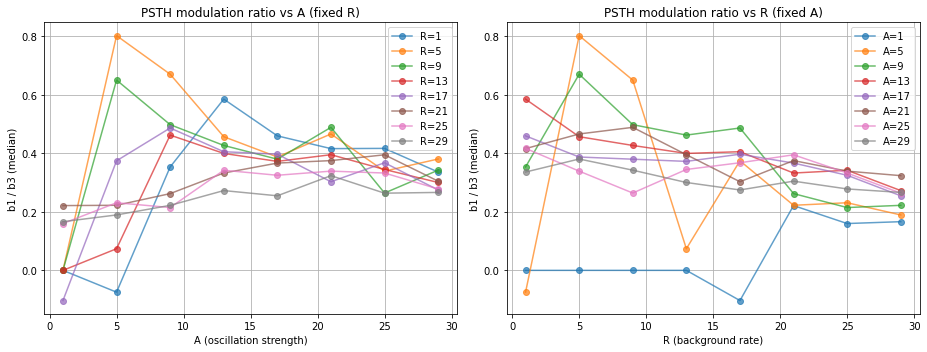

In [12]:
ratio = b1_vals / (b3_vals + 1e-12)

median_ratio_curves_A = {}
median_ratio_curves_R = {}

for R in R_unique:
    medians = []
    for A in A_unique:
        vals = ratio[(psth_A == A) & (psth_R == R)]
        medians.append(np.nan if len(vals) == 0 else np.nanmedian(vals))
    median_ratio_curves_A[R] = np.array(medians)

for A in A_unique:
    medians = []
    for R in R_unique:
        vals = ratio[(psth_A == A) & (psth_R == R)]
        medians.append(np.nan if len(vals) == 0 else np.nanmedian(vals))
    median_ratio_curves_R[A] = np.array(medians)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for R in R_unique:
    axes[0].plot(A_unique, median_ratio_curves_A[R], marker="o", alpha=0.7, label=f"R={R}")
axes[0].set_xlabel("A (oscillation strength)")
axes[0].set_ylabel("b1 / b3 (median)")
axes[0].set_title("PSTH modulation ratio vs A (fixed R)")
axes[0].legend()
axes[0].grid(True)

for A in A_unique:
    axes[1].plot(R_unique, median_ratio_curves_R[A], marker="o", alpha=0.7, label=f"A={A}")
axes[1].set_xlabel("R (background rate)")
axes[1].set_ylabel("b1 / b3 (median)")
axes[1].set_title("PSTH modulation ratio vs R (fixed A)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### 5.4 Phase locking (MVL and PPC)

1280 neuron-level locking rows
C:\ProgramData\Anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1218: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


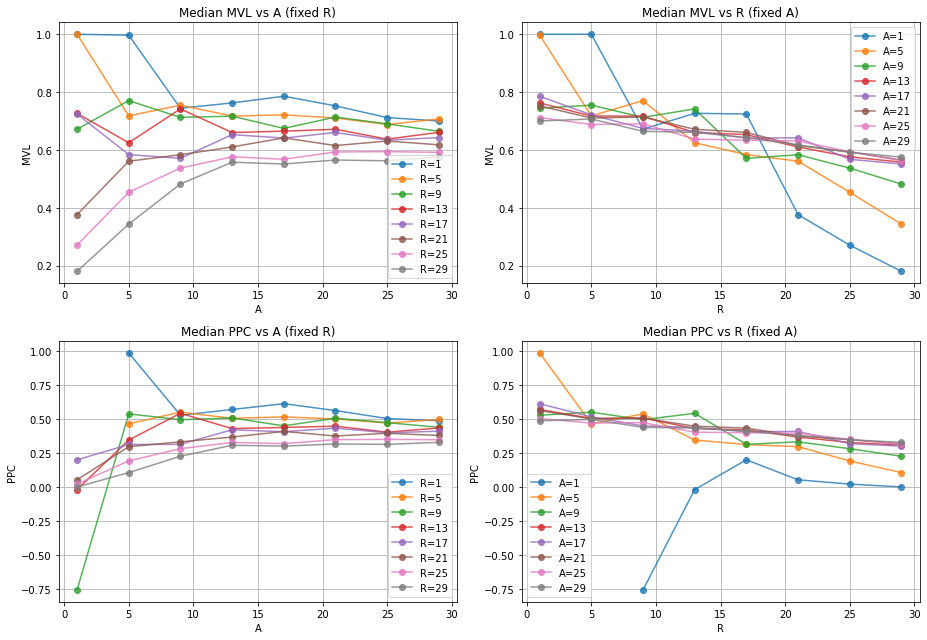

In [13]:
f_osc = sim_params["f"]
locking_table = []

for r in results:
    A = r["A"]
    R = r["R_bg"]
    time = r["time"]
    spikes_out = r["spikes_out"]
    for neuron_id in range(spikes_out.shape[0]):
        spike_times = time[spikes_out[neuron_id] == 1]
        phases, mvl, mean_phase = compute_mvl(spike_times, f=f_osc)
        ppc_val = compute_ppc(phases)
        locking_table.append({
            "A": A,
            "R": R,
            "neuron": neuron_id,
            "n_spikes": spike_times.size,
            "mvl": mvl,
            "mean_phase": mean_phase,
            "ppc": ppc_val,
        })

lock_A = np.array([row["A"] for row in locking_table])
lock_R = np.array([row["R"] for row in locking_table])
mvl_vals = np.array([row["mvl"] for row in locking_table])
ppc_vals = np.array([row["ppc"] for row in locking_table])

print(f"{len(locking_table)} neuron-level locking rows")


def median_map(metric):
    out_vs_A = {}
    out_vs_R = {}
    for R in R_unique:
        medians = []
        for A in A_unique:
            sel = metric[(lock_A == A) & (lock_R == R)]
            medians.append(np.nan if len(sel) == 0 else np.nanmedian(sel))
        out_vs_A[R] = np.array(medians)
    for A in A_unique:
        medians = []
        for R in R_unique:
            sel = metric[(lock_A == A) & (lock_R == R)]
            medians.append(np.nan if len(sel) == 0 else np.nanmedian(sel))
        out_vs_R[A] = np.array(medians)
    return out_vs_A, out_vs_R


median_mvl_vs_A, median_mvl_vs_R = median_map(mvl_vals)
median_ppc_vs_A, median_ppc_vs_R = median_map(ppc_vals)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for R in R_unique:
    axes[0, 0].plot(A_unique, median_mvl_vs_A[R], marker="o", alpha=0.8, label=f"R={R}")
    axes[1, 0].plot(A_unique, median_ppc_vs_A[R], marker="o", alpha=0.8, label=f"R={R}")
for A in A_unique:
    axes[0, 1].plot(R_unique, median_mvl_vs_R[A], marker="o", alpha=0.8, label=f"A={A}")
    axes[1, 1].plot(R_unique, median_ppc_vs_R[A], marker="o", alpha=0.8, label=f"A={A}")

axes[0, 0].set_title("Median MVL vs A (fixed R)")
axes[0, 1].set_title("Median MVL vs R (fixed A)")
axes[1, 0].set_title("Median PPC vs A (fixed R)")
axes[1, 1].set_title("Median PPC vs R (fixed A)")
for ax, xlab, ylab in [
    (axes[0, 0], "A", "MVL"),
    (axes[0, 1], "R", "MVL"),
    (axes[1, 0], "A", "PPC"),
    (axes[1, 1], "R", "PPC"),
]:
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()
